### Setting

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Importing Dependencies

In [ ]:
!pip install nltk
!pip install -U pandas-profiling
!pip install pydantic==1.10.10

In [3]:
import string
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import ydata_profiling

import numpy as np

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer


from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer, normalize

from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.cluster import SpectralClustering

from wordcloud import WordCloud

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


#### Data Load & EDA

In [18]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/Sample_Dataset.csv", encoding = 'cp949')
# data.profile_report()

### STEP 1 : Data Claeaning(Preprocess)

In [19]:
# delected data where the abstract or title information was missing or was a duplicate
data.dropna(subset=['Abstract'], inplace=True)

data.drop_duplicates(subset=['Article Title'], inplace=True)
data.drop_duplicates(subset=['Abstract'], inplace=True)

print("총 Document 수 :", data.shape[0])

총 Document 수 : 989


In [20]:
# make corpus
def combine_3rd_columns(col_1, col_2, col_3):

    result = col_1

    if not pd.isna(col_2):
        result += " " + str(col_2)

    if not pd.isna(col_3):
        result += " " + str(col_3)

    return result

data["text"] = data.apply(lambda x: combine_3rd_columns(x['Article Title'], x['Abstract'], x['Author Keywords']), axis=1)

df = data.loc[:, ['text', 'Article Title']]
df.head()

,text,Article Title
0,The development for Internet of Things smart h...,The development for Internet of Things smart h...
1,Research of Smart Home Service Platform Based ...,Research of Smart Home Service Platform Based ...
2,SHSM: A Service Middleware for Smart Home Ther...,SHSM: A Service Middleware for Smart Home
3,A Middleware of IoT-based Smart Home Based on ...,A Middleware of IoT-based Smart Home Based on ...
4,A Framework of Smart-Home Service for Elderly'...,A Framework of Smart-Home Service for Elderly'...


In [21]:
def preprocess_text(text):

    # Tokenize the text (split it into individual words)
    words = nltk.word_tokenize(text)

    # Initialize lists to hold the original and lemmatized words
    original_words = []
    lemmatized_words = []

    words = [token for token in words if token not in string.punctuation]

    for word in words:
        word = word.lower()

        if word not in stop_words and not word.isdigit() :
            lemma = lemmatizer.lemmatize(word)
            lemmatized_words.append(lemma)

            if word != lemma :
                original_words.append({word : lemma})

    # Remove numbers and rejoin the tokens into a string
    processed_text = ' '.join([token for token in lemmatized_words])

    return processed_text, original_words

# Apply the function to the 'text' column of df
df['processed_data'] = df['text'].apply(preprocess_text)

# Split the processed_data column into two separate columns: one for processed text and one for lemma pairs.
df[['corpus', 'lemma_pairs']] = pd.DataFrame(df['processed_data'].tolist(), index=df.index)

# Drop the now redundant 'processed_data' column.
df.drop(columns=['processed_data'], inplace=True)

df.head()

,text,Article Title,corpus,lemma_pairs
0,The development for Internet of Things smart h...,The development for Internet of Things smart h...,development internet thing smart home service ...,"[{'things': 'thing'}, {'things': 'thing'}, {'t..."
1,Research of Smart Home Service Platform Based ...,Research of Smart Home Service Platform Based ...,research smart home service platform based mob...,"[{'projects': 'project'}, {'products': 'produc..."
2,SHSM: A Service Middleware for Smart Home Ther...,SHSM: A Service Middleware for Smart Home,shsm service middleware smart home emerges inc...,"[{'obstacles': 'obstacle'}, {'resources': 'res..."
3,A Middleware of IoT-based Smart Home Based on ...,A Middleware of IoT-based Smart Home Based on ...,middleware iot-based smart home based service ...,"[{'presents': 'present'}, {'problems': 'proble..."
4,A Framework of Smart-Home Service for Elderly'...,A Framework of Smart-Home Service for Elderly'...,framework smart-home service elderly 's biophi...,"[{'services': 'service'}, {'supports': 'suppor..."


#### Customized rules : do not lemmatize “glasses” to “glass”



In [22]:
check_list = df.loc[:, ['lemma_pairs']]
df = df.loc[:, ['corpus', 'Article Title']]

combined_list = check_list['lemma_pairs'].sum()

def remove_duplicates(lst):
    result = []
    for item in lst:
        if item not in result:
            result.append(item)
    return result

unique_ordered_list  = remove_duplicates(combined_list)

keys, values = [], []

for d in unique_ordered_list:
    for key, value in d.items():
        keys.append(key)
        values.append(value)

checks = pd.DataFrame({'Key': keys, 'Value': values})
checks.drop_duplicates(subset=['Key'], inplace=True)
checks.drop_duplicates(subset=['Value'], inplace=True)

def check_meaning(word):
    singular = wordnet.synsets(word)
    plural = wordnet.synsets(word + 's')

    if singular and plural:
        if singular[0].definition() != plural[0].definition():
            return (True, f"'{word}': {singular[0].definition()}", f"'{word}s': {plural[0].definition()}")

    return (False, None, None)

checks['is_different'], checks['singular_def'], checks['plural_def'] = zip(*checks['Value'].map(check_meaning))

checks[checks['is_different']].to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized_1.csv', index=False)

In [23]:
df = df.loc[:, ['corpus', 'Article Title']]
df.dropna(subset=['corpus'], inplace=True)

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])

print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 989
현재 word-feature 갯수: 7755


### STEP 2 : Word-feature

#### 2-1) Deciding on the number of keywords to be selected from each item

In [24]:
# visualization function
from matplotlib.ticker import FuncFormatter

def plot_keywords(x, y, y_label, title):
    plt.figure(figsize=(10,6))

    plt.plot(x, y,  marker='o', color = 'b')

    plt.gca().invert_xaxis()

    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

    # K formatter
    k_formatter = FuncFormatter(lambda x, pos: f'K{x}')

    # Apply the formatter
    plt.gca().xaxis.set_major_formatter(k_formatter)

    plt.xlabel('Number of selected top keywords from each data')
    plt.ylabel(y_label)

    for i in [4, 5]:
        if i in x:
            index = x.index(i)
            plt.plot(i, y[index], marker='o', color='r')

    plt.title(title)
    plt.show()

In [ ]:
def plot_keywords(x, y, y_label, title):
    plt.figure(figsize=(10,6))

    plt.plot(x, y,  marker='o', color = 'b')

    # Add red dots at x = 4 and x = 5
    for i in [4, 5]:
        if i in x:
            index = x.index(i)
            plt.plot(i, y[index], marker='o', color='r')

    plt.gca().invert_xaxis()

    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

    # K formatter
    k_formatter = FuncFormatter(lambda x, pos: f'K{x}')

    # Apply the formatter
    plt.gca().xaxis.set_major_formatter(k_formatter)

    plt.xlabel('Number of selected top keywords from each data')

     # Plot the red dots on the graph
     for value in [4 ,5]:
         if value in keyword_counts:
             index_value=keyword_counts.index(value)
             mean_cosine_similarities[index_value]
             ax.plot(value ,mean_cosine_similarities[index_value] ,'ro')


   ....(나머지 코드 생략)....


##### Metric 1 : Mean of the TF-IDF scores of a word-feature across data

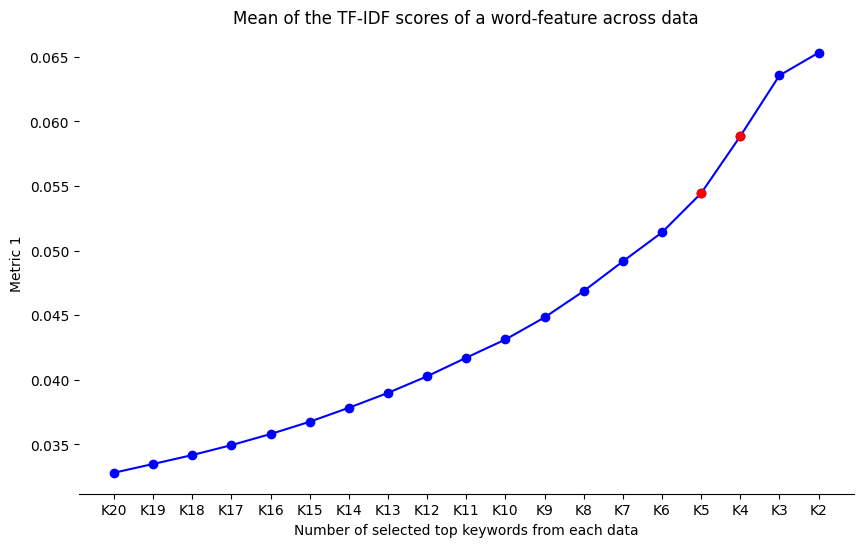

In [25]:
mean_tfidf_scores = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix.mean(axis=0)).ravel())[::-1][:count]
    mean_score = tfidf_matrix[:, top_keywords_indices].mean()
    mean_tfidf_scores.append(mean_score)

plot_keywords(keyword_counts, mean_tfidf_scores, 'Metric 1',  'Mean of the TF-IDF scores of a word-feature across data')

##### Metric 2 : Mean of the cosine similarities of a word-feature to other features

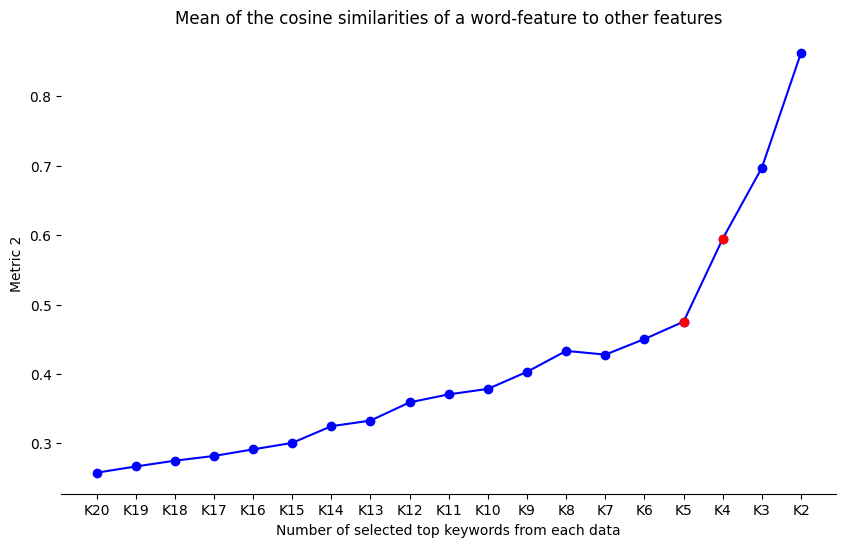

In [27]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T

mean_cosine_similarities = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    similarity_matrix = cosine_similarity(tfidf_matrix_transposed[top_keywords_indices])
    mean_similarity = np.mean(similarity_matrix[np.triu_indices(count, k=1)])
    mean_cosine_similarities.append(mean_similarity)

plot_keywords(keyword_counts, mean_cosine_similarities,'Metric 2', 'Mean of the cosine similarities of a word-feature to other features')

##### Metric 3 : Cosine similarity between a word-feature and the centroid of features

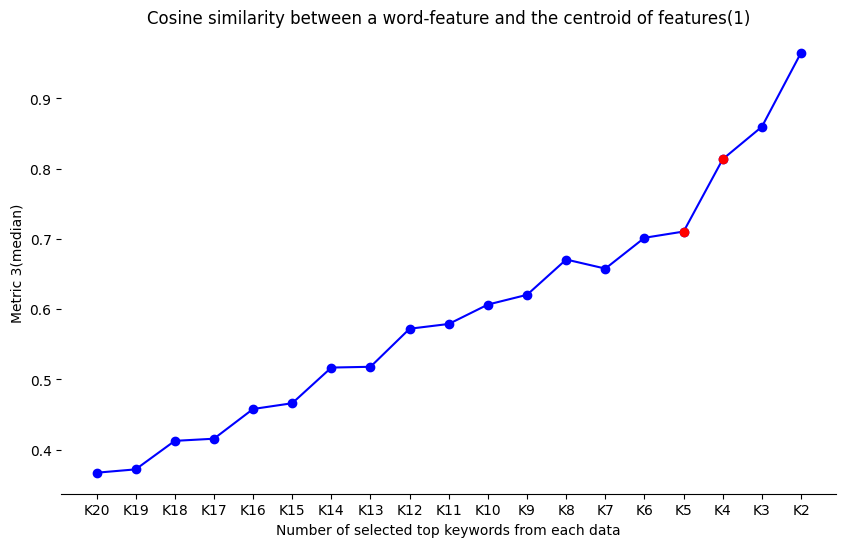

In [28]:
# meadian 사용
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.toarray().T

mean_cosine_similarities = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    centroid_vector = np.median(tfidf_matrix_transposed[top_keywords_indices], axis=0).reshape(1, -1)
    similarity_to_centroid = cosine_similarity(tfidf_matrix_transposed[top_keywords_indices], centroid_vector)
    mean_similarity_to_centroid = similarity_to_centroid.mean()
    mean_cosine_similarities.append(mean_similarity_to_centroid)

plot_keywords(keyword_counts, mean_cosine_similarities, "Metric 3(median)", "Cosine similarity between a word-feature and the centroid of features(1)")

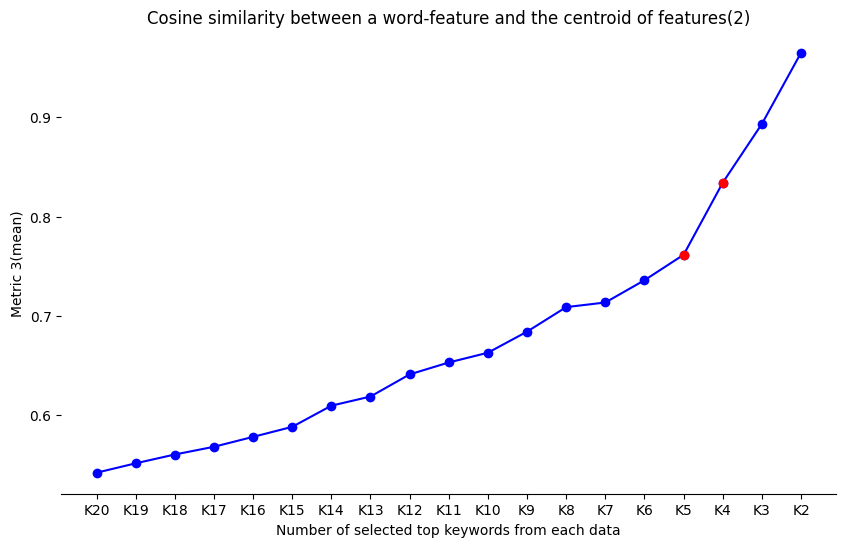

In [29]:
# 평균 사용
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.toarray().T

mean_cosine_similarities = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    centroid_vector = np.asarray(tfidf_matrix_transposed[top_keywords_indices].mean(axis=0)).reshape(1, -1)
    similarity_to_centroid = cosine_similarity(tfidf_matrix_transposed[top_keywords_indices], centroid_vector)
    mean_similarity_to_centroid = similarity_to_centroid.mean()
    mean_cosine_similarities.append(mean_similarity_to_centroid)

plot_keywords(keyword_counts, mean_cosine_similarities, "Metric 3(mean)", "Cosine similarity between a word-feature and the centroid of features(2)")

##### Metric 4 : Mean of the dot product scores of a word-feature to other features

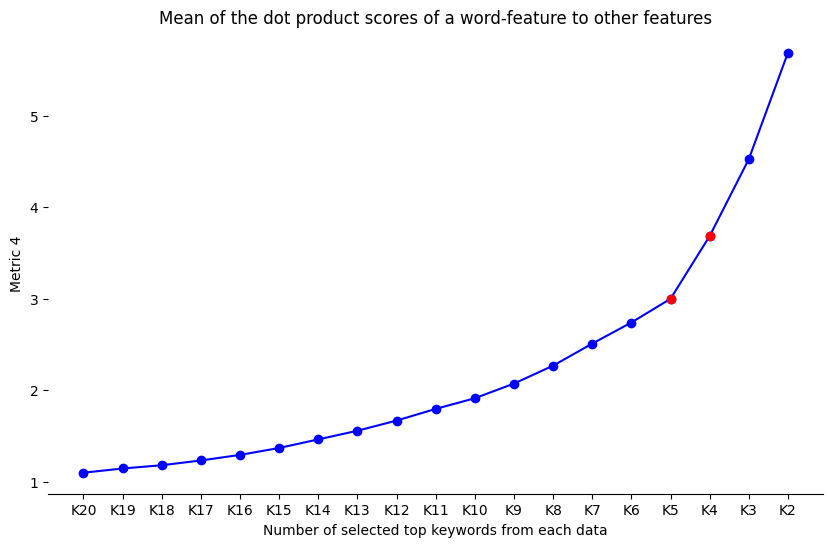

In [30]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T

mean_dot_product_scores = []
keyword_counts = list(range(20, 1, -1))

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    dot_product_matrix = np.dot(tfidf_matrix_transposed[top_keywords_indices], tfidf_matrix_transposed[top_keywords_indices].T)
    mean_dot_product_score = np.mean(dot_product_matrix[np.triu_indices(count, k=1)])
    mean_dot_product_scores.append(mean_dot_product_score)

plot_keywords(keyword_counts, mean_dot_product_scores,"Metric 4", "Mean of the dot product scores of a word-feature to other features")

##### Metric 5 : LDA score of a word-feature for the single topic of entire data set

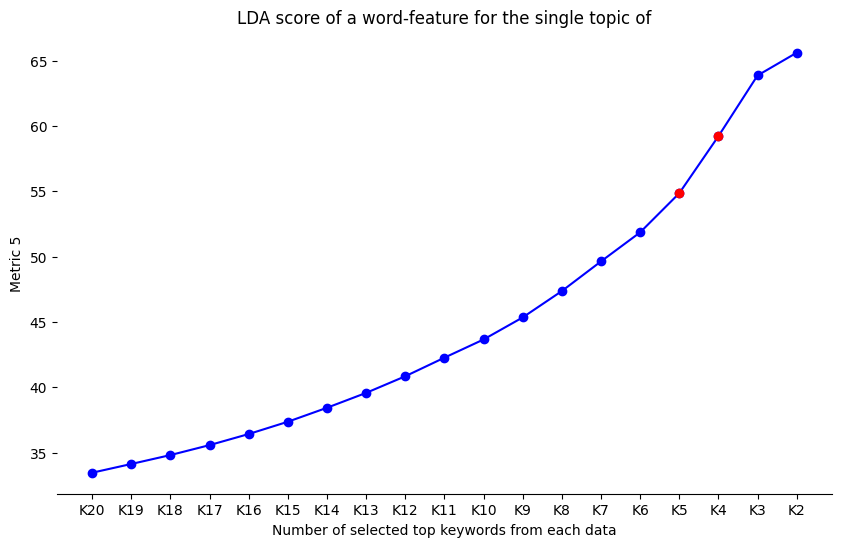

In [31]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])

lda_model = LatentDirichletAllocation(n_components=1, random_state=42)
lda_model.fit(tfidf_matrix)

mean_lda_scores = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = lda_model.components_.argsort()[0, -count:]
    mean_lda_score = lda_model.components_[0, top_keywords_indices].mean()
    mean_lda_scores.append(mean_lda_score)

plot_keywords(keyword_counts, mean_lda_scores,"Metric 5", "LDA score of a word-feature for the single topic of")

##### Result

In [32]:
# Items 당 상위 4개의 단어 선택 - Type 3 제거
top_keywords_per_document = []
feature_names = tfidf_vectorizer.get_feature_names_out()

for i in range(len(df)):
    tfidf_scores = zip(feature_names, tfidf_matrix[i].toarray()[0])
    sorted_tfidf_scores = sorted(tfidf_scores,key=lambda x: x[1], reverse=True)

    top_keywords_per_document.append([keyword for keyword,_ in sorted_tfidf_scores[:5]])

# 전체 데이터셋에서 적어도 2번 이상 나온 키워드 추출하기 - Type 1 제거
all_keywords=[keyword for document in top_keywords_per_document for keyword in document]
selected_keywords=list(set(keyword for keyword in all_keywords if all_keywords.count(keyword) >=2))

print("현재 word-feature 갯수:",len(selected_keywords))

checking = pd.DataFrame(selected_keywords, columns = ['keyword'])
checking.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/output_2.csv', index=False)

현재 word-feature 갯수: 734


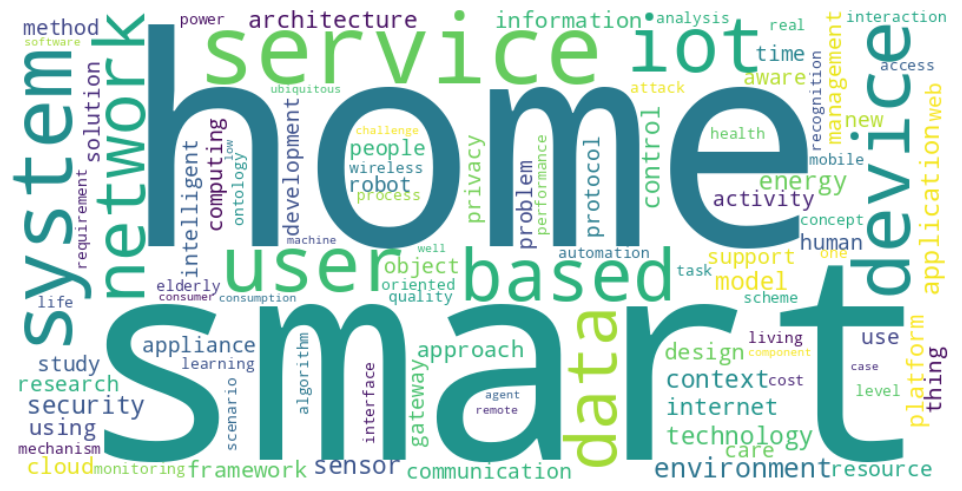

In [33]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
X = vectorizer.fit_transform(df['corpus'])

tfidf_sum = np.sum(X.toarray(), axis=0)


word_tfidf_dict = dict(zip(vectorizer.get_feature_names_out(), tfidf_sum))
top_100_words = sorted(word_tfidf_dict.items(), key=lambda x: x[1], reverse=True)[:100]
top_100_wordcloud_dict = dict(top_100_words)

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color = 'white',).generate_from_frequencies(top_100_wordcloud_dict)

# 결과 출력
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.tight_layout(pad=0)
plt.axis('off')
plt.show()

#### 2-2) Clustering based on Gaussian mixture model (GMM)

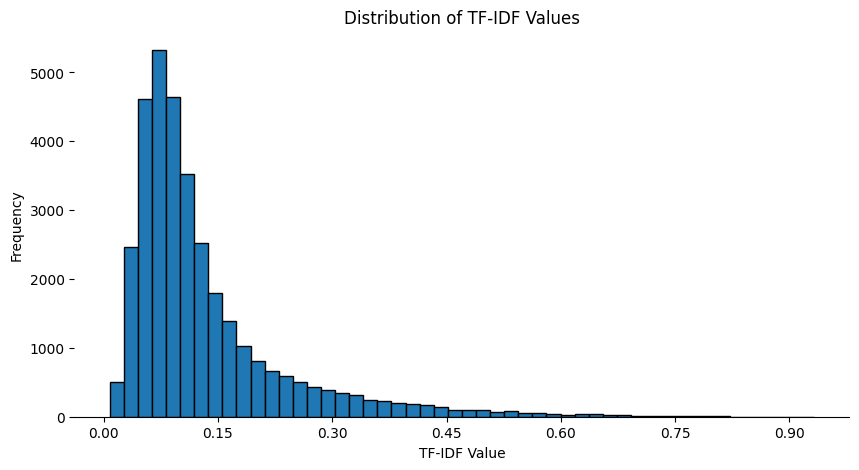

In [34]:
# Checked distribution of words : TF-IDF
tfidf_values = X.data

plt.figure(figsize=(10, 5))
plt.hist(tfidf_values, bins=50, edgecolor='black')

plt.xlabel('TF-IDF Value')
plt.ylabel('Frequency')
plt.title('Distribution of TF-IDF Values')


plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

In [35]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
X = vectorizer.fit_transform(df['corpus'])
feature_names = vectorizer.get_feature_names_out()
tfidf_matrix_transposed = X.T.toarray()

In [36]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
feature_names = vectorizer.get_feature_names_out()

tfidf_matrix = vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T.toarray()

two_keywords_set = None

for i in range(10):

    gmm = GaussianMixture(n_components=100)
    gmm.fit(tfidf_matrix_transposed)

    cluster_labels = gmm.predict(tfidf_matrix_transposed)

    df_clustered_keywords = pd.DataFrame(feature_names, columns=['keyword'])
    df_clustered_keywords['cluster'] = cluster_labels

    max_data_pointer_cluster_label = df_clustered_keywords['cluster'].value_counts().idxmax()
    max_data_pointer_cluster = df_clustered_keywords[df_clustered_keywords['cluster'] == max_data_pointer_cluster_label]['keyword'].values.tolist()
    print(f"{i + 1}번째 시행 클러스터 속 데이터 갯수:", len(max_data_pointer_cluster))

    if two_keywords_set is None:
        two_keywords_set=set(max_data_pointer_cluster)

    else:
        two_keywords_set=two_keywords_set.intersection(set(max_data_pointer_cluster))

select_keywords_list = list(two_keywords_set)
extract_keywords_list = [keyword for keyword in selected_keywords if keyword not in select_keywords_list]

print("Type1&Type3의 갯수 :", len(extract_keywords_list))
print("Type2의 갯수 :", len(select_keywords_list))

1번째 시행 클러스터 속 데이터 갯수: 501
2번째 시행 클러스터 속 데이터 갯수: 516
3번째 시행 클러스터 속 데이터 갯수: 605
4번째 시행 클러스터 속 데이터 갯수: 477
5번째 시행 클러스터 속 데이터 갯수: 520
6번째 시행 클러스터 속 데이터 갯수: 499
7번째 시행 클러스터 속 데이터 갯수: 485
8번째 시행 클러스터 속 데이터 갯수: 483
9번째 시행 클러스터 속 데이터 갯수: 518
10번째 시행 클러스터 속 데이터 갯수: 519
Type1&Type3의 갯수 : 457
Type2의 갯수 : 277


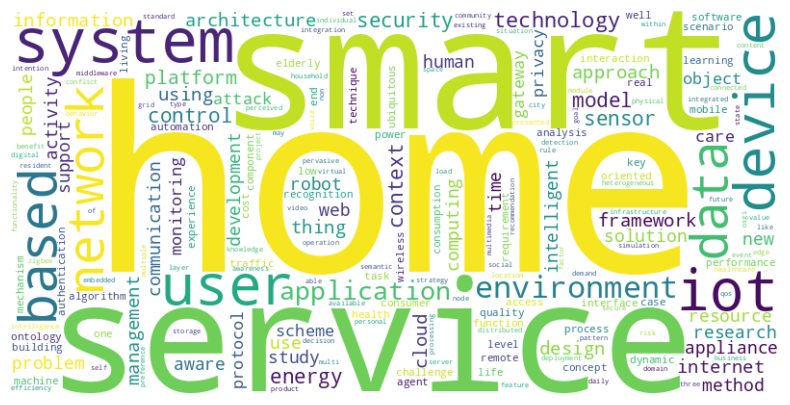

In [37]:
vectorizer = TfidfVectorizer(vocabulary=extract_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])
avg_tfidf_values = tfidf_matrix.mean(axis=0).A1
keyword_tfidf_dict = dict(zip(vectorizer.get_feature_names_out(), avg_tfidf_values))

for word, value in keyword_tfidf_dict.items():
    if np.isnan(value):
        print(f"'{word}' has a TF-IDF value of NaN.")
        keyword_tfidf_dict[word] = 0

wordcloud = WordCloud(width=800, height=400, background_color='white')
wordcloud.generate_from_frequencies(frequencies=keyword_tfidf_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

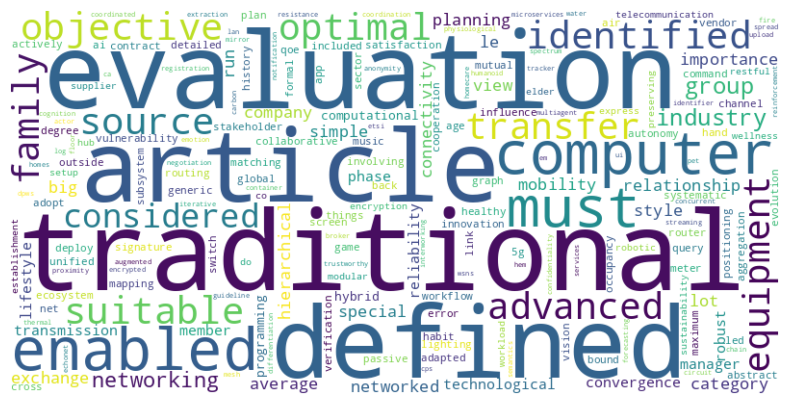

In [38]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])
avg_tfidf_values = tfidf_matrix.mean(axis=0).A1
keyword_tfidf_dict = dict(zip(vectorizer.get_feature_names_out(), avg_tfidf_values))

for word, value in keyword_tfidf_dict.items():
    if np.isnan(value):
        print(f"'{word}' has a TF-IDF value of NaN.")
        keyword_tfidf_dict[word] = 0


wordcloud = WordCloud(width=800, height=400, background_color='white')
wordcloud.generate_from_frequencies(frequencies=keyword_tfidf_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [39]:
checking_1= pd.DataFrame(select_keywords_list, columns = ['keyword'])
checking_1.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/select_output_2.csv', index=False)

checking_2 = pd.DataFrame(extract_keywords_list, columns = ['keyword'])
checking_2.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/extract_output_2.csv', index=False)

###  STEP 3 : Eliminated outliers by calculating the cosine similarities

In [40]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])
similarity_matrix = cosine_similarity(tfidf_matrix)
similarity_matrix

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [41]:
mean_cosine_similarities = similarity_matrix.mean(axis=1)
lowest_100_indices = np.argsort(mean_cosine_similarities)[:100]
lowest_100_titles = df.loc[lowest_100_indices, 'Article Title']

lowest_100_titles.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/lowest_100_titles.csv', index=False)

### STEP 4 : Descriptive analysis - Spectral Clustering

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(verbose=1, perplexity=50)  # Changed perplexity from 100 to 50 per FAQ
X_embedded = tsne.fit_transform(X.toarray())

In [ ]:
# 1. Principal Component Analysis (PCA)
pca = PCA(n_components=2)
tfidf_matrix_filtered_pca = pca.fit_transform(tfidf_matrix.toarray())

In [46]:
from sklearn.decomposition import TruncatedSVD
# 1. Principal Component Analysis (PCA)
pca = TruncatedSVD(n_components=2)
tfidf_matrix_filtered_pca = pca.fit_transform(tfidf_matrix.toarray())

# 2. Clustering range 설정 (2개에서 50개)
cluster_range = range(2, 40)

# 3 & 4. Spectral clustering and evaluation
cosine_scores_avg, euclidean_scores_avg = [], []

for n_clusters in cluster_range:
    cosine_scores, euclidean_scores = [], []

    for _ in range(10): # Repeat the process for 10 times

        # Perform spectral clustering
        spectral_clustering = SpectralClustering(n_clusters=n_clusters)
        labels = spectral_clustering.fit_predict(tfidf_matrix_filtered_pca)

        # Calculate silhouette scores for cosine and euclidean distances
        score_cosine = silhouette_score(tfidf_matrix_filtered_pca, labels,
                                        metric='cosine')
        score_euclidean = silhouette_score(tfidf_matrix_filtered_pca, labels,
                                           metric='euclidean')

        cosine_scores.append(score_cosine)
        euclidean_scores.append(score_euclidean)

    cosine_scores_avg.append(np.mean(cosine_scores))
    euclidean_scores_avg.append(np.mean(euclidean_scores))

#5 Plotting the results.
plt.figure(figsize=(10,6))
plt.plot(cluster_range, cosine_scores_avg,'-o', label='Cosine')
plt.plot(cluster_range, euclidean_scores_avg,'-o', label='Euclidian')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Silhouette Score')

plt.grid(True)

plt.legend()
plt.show()

KeyboardInterrupt: ignored

In [ ]:
# Perform spectral clustering with 16 clusters
spectral_clustering = SpectralClustering(n_clusters=16)
labels = spectral_clustering.fit_predict(tfidf_matrix_filtered_pca)

# Extract feature names from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Initialize a list to hold the top keywords for each cluster
cluster_keywords_summary = []

# Iterate over each cluster
for i in range(16):
    # Get the indices of the documents in this cluster
    cluster_docs_indices = np.where(labels == i)[0]

    # Get the TF-IDF matrix for these documents only
    cluster_tfidf = tfidf_matrix_filtered[cluster_docs_indices]

    # Sum the TF-IDF scores for each term and sort them in descending order
    summed_tfidf_scores = np.sum(cluster_tfidf, axis=0)
    sorted_term_indices = np.argsort(summed_tfidf_scores)[::-1]

    # Get the top 10 terms for this cluster and append them to our summary list
    top_term_indices = sorted_term_indices[:10].tolist()[0]
    top_terms = [feature_names[idx] for idx in top_term_indices]

    cluster_keywords_summary.append(top_terms)

# Print out the results:
for i, keywords in enumerate(cluster_keywords_summary):
   print(f"Cluster {i+1}: {', '.join(keywords)}")

Cluster 1: 000, inventory, inverse, invitation, involvement, io, ioe, iopat, iorl, iotams, iotcloud, iotivity, invade, iots, iottalk, ipchain, ipfs, ipv4, ipv6, ir, iroot, irrelevant, irresistible, is, iso, iotshs, intrusiveness, intruder, intrinsic, interactions, interactivity, intercept, intercloud, interconnect, interconnectedness, interconnectivity, interconnects, interfering, intermediary, internally, interoperation, interoperations, interplanetary, interplay, interpolation, interpreted, interpreter, interrelationship, interrupted, interweaved, intimate, intra, intranet, intriguing, isolating, issued, ist, it, kottayam, kumar, kwh, ky, kyung, label, labeled, labeling, labelled, labor, labview, laplace, laptop, largest, late, launch, launching, layered, laying, leaf, leaked, leaking, ledger, left, legacy, knowledgeable, interactional, knowing, kinematic, ivr, ization, jamming, jamura, jess, jitter, john, join, jordanian, js, json, jtc, judging, jurik, justifying, juvenile, jwt, kal